# Install and Import

In [5]:
!pip install gymnasium

   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   --- ------------------------------------ 71.7/952.1 kB 1.3 MB/s eta 0:00:01
   --------------------------------------- 952.1/952.1 kB 12.1 MB/s eta 0:00:00


In [13]:
!pip install imageio imageio-ffmpeg

   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.2 MB 1.4 MB/s eta 0:00:23
   --- ------------------------------------ 2.7/31.2 MB 34.3 MB/s eta 0:00:01
   --------- ------------------------------ 7.3/31.2 MB 58.1 MB/s eta 0:00:01
   --------------- ------------------------ 11.8/31.2 MB 93.0 MB/s eta 0:00:01
   --------------------- ------------------ 16.7/31.2 MB 93.9 MB/s eta 0:00:01
   --------------------------- ------------ 21.2/31.2 MB 93.9 MB/s eta 0:00:01
   --------------------------------- ------ 26.2/31.2 MB 93.9 MB/s eta 0:00:01
   ---------------------------------------  31.2/31.2 MB 108.8 MB/s eta 0:00:01
   ---------------------------------------  31.2/31.2 MB 108.8 MB/s eta 0:00:01
   ---------------------------------------  31.2/31.2 MB 108.8 MB/s eta 0:00:01
   ---------------------------------------  31.2/31.2 MB 108.8 MB/s eta 0:00:01
   ---------------------------------------- 31.2/31.2 MB 40.9

In [1]:
!pip install pygame

In [173]:
# Core and Utilities
import os
import time
import random
import numpy as np
from collections import deque
from itertools import count
import matplotlib.pyplot as plt

# Gym Environment
import gymnasium as gym
from gymnasium import spaces

# Rendering, Sprites, and Video
import pygame                       # Human playtesting
from PIL import Image, ImageDraw    # Sprite loading
from IPython.display import display, Video
import imageio                      # Video export  

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from torch.utils.data import DataLoader, TensorDataset

# Prepare Environment

In [439]:
## Try to load sprite; fallback to colored box if missing
def load_or_fallback(path, fallback_color='red', size=(24, 24)):
    try:
        sprite = Image.open(path).convert("RGB").resize(size)
    except FileNotFoundError:
        sprite = Image.new("RGB", size, fallback_color)
    return sprite


## Junimo Kart, 2D RGB Environment
class JunimoKartEnv(gym.Env):
    ## ----- Initialization (constructor, spaces, sprites) -----
    def __init__(self, view_distance=20, max_time=900):
        super().__init__()

        # Tilemap settings
        self.HEIGHT = 14
        self.view_distance = view_distance
        self.max_time = int(max(max_time, 40))

        # Ground height limits
        self.MIN_GROUND = 1
        self.MAX_GROUND = 8
        self.PIT = -1

        # Pit generation parameters
        self.PIT_PROB = 0.08
        self.PIT_LENGTH_MIN = 4
        self.PIT_LENGTH_MAX = 8
        self.PIT_COOLDOWN = 25

        # Coin Cooldown parameter
        self.COIN_COOLDOWN = 10
        self.coin_cd = 0

        # Object cooldown parameter
        self.OBJECT_COOLDOWN = 8 # / 2 since air boulders and regular obstacles count differently
        self.obstacle_cd = 0

        # Physics settings
        self.gravity = -0.7
        self.jump_strength = 4.0
        self.jump_boost = 0.3
        self.jump_max_hold = 7

        # Player position
        self.player_col = 2
        self.player_x_pix_offset = 40
        self.y = 0.0
        self.y_vel = 0.0
        self.jump_hold = 0

        # Observation Space
        # platforms, boulders, roadblocks, coins, fruits
        self.num_channels = 5
        self.tile_obs_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(self.num_channels, self.HEIGHT, self.view_distance),
            dtype=np.float32
        )

        # Player state = [y, y_vel, on_ground, pit_dist_norm, fruit_dist_norm, next_ground_norm], column is always the same
        self.state_obs_space = spaces.Box(
            low=np.array([0.0, -10.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([self.HEIGHT, 10.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
        )

        # Full space
        self.observation_space = spaces.Dict({
            "tiles": self.tile_obs_space,
            "state": self.state_obs_space,
        })

        # Action Space
        self.action_space = spaces.Discrete(2) # 0=nojump, 1=jump/hold

        # Rendering
        self.tile_size = 24
        self.screen_width = self.tile_size * (self.view_distance + 3)
        self.screen_height = self.tile_size * self.HEIGHT

        self.sprite_player =    load_or_fallback('assets/player.png', fallback_color=(0,255,0), size=(self.tile_size, self.tile_size))
        self.sprite_platform =  load_or_fallback('assets/platform.png', fallback_color=(100,100,100), size=(self.tile_size, self.tile_size))
        self.sprite_boulder =   load_or_fallback('assets/boulder.png', fallback_color=(200,0,0), size=(self.tile_size, self.tile_size))
        self.sprite_roadblock = load_or_fallback('assets/roadblock.png', fallback_color=(255,128,0), size=(self.tile_size, self.tile_size))
        self.sprite_coin =      load_or_fallback('assets/coin.png', fallback_color=(255,215,0), size=(self.tile_size, self.tile_size))

        # 3 fruit sprites used in a fixed order
        self.sprite_fruitA = load_or_fallback('assets/fruitA.png', fallback_color=(255,50,150), size=(self.tile_size, self.tile_size))
        self.sprite_fruitB = load_or_fallback('assets/fruitB.png', fallback_color=(0,180,255), size=(self.tile_size, self.tile_size))
        self.sprite_fruitC = load_or_fallback('assets/fruitC.png', fallback_color=(200,0,255), size=(self.tile_size, self.tile_size))

        self.reset()


    ## ----- Reset Logic -----
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.rng = np.random.default_rng(seed)

        # Timers and state
        self.t = 0
        self.in_pit = False
        self.pit_remaining_length = 0
        self.last_pit_length = 0
        self.pit_cooldown = self.PIT_COOLDOWN
        self.after_pit_counter = 0
        self.allow_jump_after = 2 # Begin, user should be able to act after 2 frames
        self.coin_cd = 0
        self.obstacle_cd = 0

        # Initialize ground heights
        self.ground = np.zeros(self.view_distance, dtype=int)

        # Terrain generation for initial chunk
        START_LEN = 12
        start_height = self.rng.integers(self.MIN_GROUND + 1, self.MAX_GROUND - 1)

        for j in range(START_LEN): # Safe, flat terrain
            self.ground[j] = start_height
        for j in range(START_LEN, self.view_distance): # Initial terrain past required safe terrain
            self._generate_next_ground_column(j-1, j)

        # Allocate tile layers
        self.platforms =  np.zeros((self.HEIGHT, self.view_distance), dtype=np.float32)
        self.boulders =   np.zeros_like(self.platforms)
        self.roadblocks = np.zeros_like(self.platforms)
        self.coins =      np.zeros_like(self.platforms)
        self.fruits =     np.zeros_like(self.platforms)

        # Build platforms based on ground and fill objects
        self._rebuild_platforms()
        self._random_fill_objects_initial()

        # Safe starting zone, remove objects
        for j in range(START_LEN):
            self.boulders[:, j] = 0.0
            self.roadblocks[:, j] = 0.0
            self.coins[:, j] = 0.0
            self.fruits[:, j] = 0.0

        # Place spawn
        g = self.ground[self.player_col]
        if g == self.PIT: # Safety check
            g = start_height
        self.y = g + 1.0
        self.y_vel = 0.0
        self.jump_hold = 0

        # Fruit scheduling; 3 fruits
        first_fruit_col = max(START_LEN + 1, 12) # Never in safe region
        last_fruit_col = self.max_time - 10
        self.fruit_spawn_columns = self._generate_spaced_fruit_columns(first_fruit_col, last_fruit_col, count=3, min_gap=15)
        self.fruit_spawn_order = ['A', 'B', 'C'] # Always appear in order for sprites
        self.fruit_type_map = {}
        self.fruits_collected = 0

        self.eval_score = 0
        return self._get_obs(), {}

    def set_max_time(self, max_time):
        self.max_time = int(max(max_time, 40))


    ## ----- Terrain Generation Helpers -----
    def _generate_next_ground_column(self, prev_j, j):
        prev = self.ground[prev_j]

        # If not in a pit, increment after_pit_counter
        if not self.in_pit:
            self.after_pit_counter += 1
        
        # Case 1: Currently inside a pit
        if self.in_pit:
            self.ground[j] = self.PIT
            self.pit_remaining_length -= 1
            if self.pit_remaining_length == 0: # Pit ends
                self.in_pit = False
                self.pit_cooldown = self.rng.integers(self.PIT_COOLDOWN - 1, self.PIT_COOLDOWN + 1) # Some pits will have a smaller possible cooldown, some larger
                self.pit_cooldown = max(2, self.pit_cooldown) # Ensure platforms are possible
                self.after_pit_counter = 0
            return

        # Case 2: Ground, pit cooldown active
        if self.pit_cooldown > 0:
            self.pit_cooldown -= 1
            # Dynamically pick landing height for fairness if pit
            if prev == self.PIT:
                L = self.last_pit_length
                J = self.jump_strength
                # Choose platform landing area limited by jump
                max_platform = int(np.floor(J - 0.5 * L))
                max_platform = int(np.clip(max_platform, self.MIN_GROUND, self.MAX_GROUND))
                prev = self.rng.integers(self.MIN_GROUND, max_platform + 1)
            # Apply gentle slope variation
            real_prev = self.ground[prev_j]
            if real_prev != self.PIT:
                delta = self.rng.choice([-1,0,1], p=[0.05,0.9,0.05])
                prev = np.clip(prev, real_prev - 1, real_prev + 1)
                new = int(np.clip(prev + delta, self.MIN_GROUND, self.MAX_GROUND))
                self.ground[j] = new
            return

        # Case 3: After cooldown, maybe begin a pit
        if self.rng.random() < self.PIT_PROB:
            self.in_pit = True
            L = self.rng.integers(self.PIT_LENGTH_MIN, self.PIT_LENGTH_MAX + 1)
            self.pit_remaining_length = L
            self.last_pit_length = L
            self.ground[j] = self.PIT
            return

        # Case 4: Normal terrain if not begin pit
        if prev == self.PIT: # Should not normally happen as Case 2 should handle this
            prev = self.MIN_GROUND
        delta = self.rng.choice([-1,0,1], p=[0.1,0.8,0.1]) # after cooldown, a bit more bumpy
        new = int(np.clip(prev + delta, self.MIN_GROUND, self.MAX_GROUND))
        self.ground[j] = new

    def _spawn_new_ground_column(self):
        self.ground = np.roll(self.ground, -1)
        self._generate_next_ground_column(self.view_distance - 2, self.view_distance - 1)

    def _last_solid_ground_height(self):
        for j in range(self.view_distance - 1, -1, -1):
            g = self.ground[j]
            if g != self.PIT:
                return g
        return self.MIN_GROUND # Should not occur normally

    def _scroll_fruit_types(self):
        new_map = {}
        for k, v in self.fruit_type_map.items():
            if k > 0:
                new_map[k-1] = v
        self.fruit_type_map = new_map

    def _generate_spaced_fruit_columns(self, first_col, last_col, count=3, min_gap=15):
        cols = []
        attempts = 0
        max_attempts = 1500

        while len(cols) < count and attempts < max_attempts:
            attempts += 1
            candidate = self.rng.integers(first_col, last_col)
            if all(abs(candidate - col) >= min_gap for col in cols):
                cols.append(candidate)

        # Fallback, evenly spaced fruit columns
        if len(cols) < count:
            span = last_col - first_col
            interval = span / (count - 1)
            cols = []
            for i in range(count):
                jitter = self.rng.integers(-2, 3)
                pos = int(np.clip(first_col + i * interval + jitter, first_col, last_col))
                cols.append(pos)

        return sorted(cols)


    ## ----- Tile Construction and Object Placement -----
    def _rebuild_platforms(self):
        self.platforms.fill(0.0)
        for j in range(self.view_distance):
            g = self.ground[j]
            if g != self.PIT:
                self.platforms[0:g+1, j] = 1.0

    def _near_fruit_spawn(self, col, radius=7):
        return any(abs(col - c) <= radius for c in self.fruit_spawn_columns)

    def _random_fill_objects_initial(self):
        self.boulders.fill(0.0)
        self.roadblocks.fill(0.0)
        self.coins.fill(0.0)
        self.fruits.fill(0.0)

        for j in range(self.view_distance):
            g = self.ground[j]
            if g == self.PIT:
                continue
            if self.rng.random() < 0.15:
                self.boulders[g+1, j] = 1.0
            if self.rng.random() < 0.05:
                self.boulders[:,j] = 0.0
                self.roadblocks[g+1, j] = 1.0
            if self.rng.random() < 0.1:
                r = min(g + 2, self.HEIGHT - 1)
                self.coins[r, j] = 1.0

    def _spawn_new_column(self):
        j = self.view_distance - 1
        g = self.ground[j]

        self.platforms[:, j] = 0.0
        self.boulders[:, j] = 0.0
        self.roadblocks[:, j] = 0.0
        self.coins[:, j] = 0.0
        self.fruits[:, j] = 0.0

        if g != self.PIT:
            self.platforms[0:g+1, j] = 1.0

        # Helper: compute variable height for object
        def compute_var_height(low = 3, high = 5):
            variable_height = self.rng.integers(low, high)
            if g == self.PIT:
                last_ground = self._last_solid_ground_height()
            else:
                last_ground = g
            return min(last_ground + variable_height, self.HEIGHT - 1)

        # Fruit spawning
        fruit_spawned = False
        if self.t in self.fruit_spawn_columns:
            idx = self.fruit_spawn_columns.index(self.t)
            fruit_type = self.fruit_spawn_order[idx]

            fruit_row = compute_var_height(low=4,high=5)
            self.fruits[fruit_row, j] = 1.0
            self.fruit_type_map[j] = fruit_type
            fruit_spawned = True

        # Coins
        coin_spawned = False
        if (not fruit_spawned):
            if self.coin_cd <= 0:
                r = self.rng.random()
                if r < 0.1:
                    self.coins[compute_var_height(), j] = 1.0
                    self.coin_cd = self.COIN_COOLDOWN
                    coin_spawned = True
            else:
                self.coin_cd -= 1

        # Prevent obstacles if fruits are nearby or if we just finished a pit
        if self._near_fruit_spawn(self.t) or self.after_pit_counter <= 6:
            return

        # Obstacles
        object_spawned = False
        if g != self.PIT:
            if self.obstacle_cd <= 0:
                r = self.rng.random()
                if r < 0.045:
                    self.boulders[g+1, j] = 1.0
                    object_spawned = True
                    if self.rng.random() < 0.99: # Encourage clustering but not too often
                        self.obstacle_cd = self.OBJECT_COOLDOWN
                elif r < 0.075:
                    self.roadblocks[g+1, j] = 1.0
                    object_spawned = True
                    if self.rng.random() < 0.99:
                        self.obstacle_cd = self.OBJECT_COOLDOWN
            else:
                self.obstacle_cd -= 1

        # Airborne boulders (anti jump spam obstacles)
        if (not fruit_spawned) and (not coin_spawned) and (not object_spawned) and g != self.PIT:
            if self.rng.random() < 0.1 and self.obstacle_cd <= 0:
                # Airborne height 3-6 tiles above last ground
                r = compute_var_height(low=3, high=6)
                max_stack = 4
                stack_chance = 0.4
                current_r = r

                for _ in range(max_stack):
                    if current_r < self.HEIGHT:
                        self.boulders[current_r, j] = 1.0
                    else:
                        break
                        
                    if self.rng.random() > stack_chance:
                        break
                    current_r += 1
                self.obstacle_cd = self.OBJECT_COOLDOWN
            else:
                self.obstacle_cd -= 1


    ## ----- Player state and physics helpers -----
    def _is_on_ground(self):
        c = self.player_col
        g = self.ground[self.player_col]

        # Normal ground check
        if g != self.PIT:
            ground_y = g + 1.0
            if abs(self.y - ground_y) < 0.05:
                return True

        # Coyote Time ground Check (platform behind and below)
        behind_c = c - 1
        if behind_c >= 0:
            behind_g = self.ground[behind_c]
            if behind_g != self.PIT:
                behind_ground_y = behind_g + 1.0
                if 0 < self.y - behind_ground_y < 0.2:
                    return True

        return False


    def _is_on_boulder(self):
        r = int(np.clip(round(self.y), 0, self.HEIGHT - 1))
        below = r - 1
        if below < 0:
            return False
        return self.boulders[below, self.player_col] == 1.0


    ## ----- Observation Builder (for our RL model) -----
    def _get_obs(self):
        ## --- Conv Space (CNN)
        tiles = np.stack([
            self.platforms,
            self.boulders,
            self.roadblocks,
            self.coins,
            self.fruits
        ], axis=0).astype(np.float32)

        ## --- State space
        c = self.player_col

        # Tracks whether player is on the ground
        on_ground = self._is_on_ground()

        # Tracks distance to next pit and next fruit
        pit_dist = self.view_distance
        for d in range (1, self.view_distance - c):
            if self.ground[c+d] == self.PIT:
                pit_dist = d
                break
        pit_dist_norm = pit_dist / self.view_distance
        
        fruit_dist = self.view_distance
        for d in range (1, self.view_distance - c):
            if np.any(self.fruits[:,c+d] == 1.0):
                fruit_dist = d
                break
        fruit_dist_norm = fruit_dist / self.view_distance

        
        # Tracks ground height one tile ahead
        next_ground = self.ground[c + 1]
        if next_ground == self.PIT:
            next_ground = -1
        next_ground_norm = (next_ground + 1) / (self.MAX_GROUND + 2)

        # Final state vector
        state = np.array([
            self.y, 
            self.y_vel, 
            on_ground,
            pit_dist_norm,
            fruit_dist_norm,
            next_ground_norm
        ], dtype=np.float32)

        return {"tiles": tiles, "state": state}


    ## ----- Step Function; physics, scrolling, rewards, death -----
    def step(self, action):
        self.t += 1
        reward = 0.0
        terminated = False
        truncated = False

        # Jump Logic
        self.allow_jump_after -= 1
        can_jump = (self.allow_jump_after <= 0)
        if action == 1 and can_jump:
            if self._is_on_ground() or self._is_on_boulder(): # Start Jump
                self.y_vel = self.jump_strength
                self.jump_hold = 1

            else: # Hold jump if not on ground
                if 0 <= self.jump_hold < self.jump_max_hold:
                    # Continue jump if still holding jump
                    self.y_vel += self.jump_boost
                    self.jump_hold += 1
        else:
            # Jump button released
            if self._is_on_ground() or self._is_on_boulder(): # End Jump
                self.jump_hold = 0

        # Physics
        prev_y = self.y
        self.y_vel += self.gravity
        self.y = max(0.0, self.y + self.y_vel * 0.3)

        # Store for reward for later
        was_pit = (self.ground[self.player_col] == self.PIT)

        # Scroll world
        self.platforms =  np.roll(self.platforms, -1, axis=1)
        self.boulders =   np.roll(self.boulders, -1, axis=1)
        self.roadblocks = np.roll(self.roadblocks, -1, axis=1)
        self.coins =      np.roll(self.coins, -1, axis=1)
        self.fruits =     np.roll(self.fruits, -1, axis=1)

        self._scroll_fruit_types()
        self._spawn_new_ground_column()
        self._spawn_new_column()

        # Check ground collision against the new column for the player
        g = self.ground[self.player_col]
        if g != self.PIT:
            ground_y = g + 1.0

            # Wall check, if "snap" would pull agent up > 2 tiles, wall hit and death
            height_diff = ground_y - prev_y
            if height_diff > 2.0:
                reward -= 4.5
                terminated = True
                return self._get_obs(), reward, terminated, truncated, {"score": self.eval_score}

            # Normal, safe landing and snap up from slope
            if self.y <= ground_y:
                self.y = ground_y
                self.y_vel = 0
                self.jump_hold = 0

        # Tile positions
        r = int(np.clip(round(self.y), 0, self.HEIGHT - 1))
        c = self.player_col
        ahead = min(c + 1, self.view_distance - 1)

        # Pit death
        if g == self.PIT and self.y < 0.5:
            reward -= 4.5
            terminated = True
            return self._get_obs(), reward, terminated, truncated, {"score": self.eval_score}

        # Coin collection
        if self.coins[r, c] == 1.0:
            reward += 3.0
            self.coins[r, c] = 0.0
            self.eval_score += 40

        # Fruit collection
        if self.fruits[r, c] == 1.0:
            reward += 15.0 
            self.fruits[r, c] = 0.0
            if c in self.fruit_type_map:
                del self.fruit_type_map[c]
            self.fruits_collected += 1
            self.eval_score += 1000

        ## Obstacle Collision
        top_y = r + 1.0
        hit_boulder_now = (self.boulders[r, c] == 1.0)
        hit_roadblock_now = (self.roadblocks[r, c] == 1.0)
        hit_boulder_ahead = (self.boulders[r, ahead] == 1.0)
        hit_roadblock_ahead = (self.roadblocks[r, ahead] == 1.0)
        landing_from_above = (prev_y > top_y - 0.3) and (self.y <= top_y + 0.1)

        # Roadblock
        if hit_roadblock_now or hit_roadblock_ahead:
            # Stomp attempt
            if landing_from_above:
                self.roadblocks[r, c] = 0.0
                self.roadblocks[r, ahead] = 0.0

                self.y = top_y
                self.y_vel = 4.0
                self.jump_hold = 0
                reward += 0.03
                self.eval_score += 10
            else:
                reward -= 4.5
                terminated = True
                return self._get_obs(), reward, terminated, truncated, {"score": self.eval_score}

        # Boulder
        if hit_boulder_now or hit_boulder_ahead:
            if landing_from_above:
                reward += 0.03
                self.y = top_y
                self.y_vel = 0
                self.jump_hold = 0
            else:
                reward -= 4.5
                terminated = True
                return self._get_obs(), reward, terminated, truncated, {"score": self.eval_score}

        # Level complete
        if self.t >= self.max_time:
            truncated = True
            if self.fruits_collected == 3:
                # Reward shaping, training already rewards heavily for fruit collection, so only eval
                self.eval_score += 5000
            reward += 20.0
            self.eval_score += 5000
        
        # Rewards
        reward += 0.01 # Survival reward
        self.eval_score += 10
        
        ## Reward Shaping
        # Reward jumping when approaching a pit
        if action == 1 and self._is_on_ground():
            # Penalize jump spamming
            reward -= 0.005
            for d in range(1, 4): # look 3 tiles ahead
                j = c + d
                if j < self.view_distance and self.ground[j] == self.PIT:
                    # reward for jumping when pit is closer
                    reward += (4 - d) * 0.01
                    break

        # Reward for surviving pit (column 2 was pit)
        if was_pit and g != self.PIT:
            reward += 0.5

        return self._get_obs(), reward, terminated, truncated, {"score": self.eval_score}


    ## ----- Rendering (RGB image) -----
    def render(self, include_player=True):
        img = Image.new('RGB', (self.screen_width, self.screen_height), (135, 206, 235))

        for j in range(self.view_distance):
            x = self.player_x_pix_offset + j * self.tile_size
            for r in range(self.HEIGHT):
                y = self.screen_height - (r + 1) * self.tile_size

                # Render objects
                if self.platforms[r, j] == 1.0:
                    img.paste(self.sprite_platform, (x, y))
                if self.boulders[r, j] == 1.0:
                    img.paste(self.sprite_boulder, (x, y))
                if self.roadblocks[r, j] == 1.0:
                    img.paste(self.sprite_roadblock, (x, y))
                if self.coins[r, j] == 1.0:
                    img.paste(self.sprite_coin, (x, y))
                if self.fruits[r, j] == 1.0:
                    ftype = self.fruit_type_map.get(j, 'A')
                    if ftype == 'A':
                        img.paste(self.sprite_fruitA, (x, y))
                    elif ftype == 'B':
                        img.paste(self.sprite_fruitB, (x, y))
                    elif ftype == 'C':
                        img.paste(self.sprite_fruitC, (x, y))
                    else:
                        raise ValueError(f"Unknown fruit type: {ftype}") # Error, only 3 fruits in a stage

        # Player
        if include_player:
            r = int(np.clip(round(self.y), 0, self.HEIGHT - 1))
            px = self.player_x_pix_offset + self.player_col * self.tile_size
            py = self.screen_height - (r + 1) * self.tile_size
            img.paste(self.sprite_player, (px, py))

        big = img.resize((self.screen_width * 2, self.screen_height * 2), Image.NEAREST)
        return big


## Test gym environment.
 - The code below uses pygame to allow the user to play the game. It converts the PIL Images generated by the render function to Surfaces, that can be displayed on Pygame
 - Additionally, rather than each frame being a scroll on the column (very choppy gameplay), I added a scroll pixels per frame parameter, which allows the screen to scroll for more smooth gameplay. The player is rendered separately to match this smoother scrolling, which we can do by setting include_player parameter to False in our JunimoKartEnv.

In [280]:
# tile sizes and smoothing frames
TILE_SIZE = 24
SCROLL_PIXELS_PER_FRAME = 2  # smooth scrolling

# Convert PIL Image to Surface for pygame
def pil_to_pygame(pil_img):
    mode = pil_img.mode
    size = pil_img.size
    data = pil_img.tobytes()
    return pygame.image.fromstring(data, size, mode)

# Allow a human to play the game
def play_junimo_kart():
    env = JunimoKartEnv(view_distance=20, max_time=900)
    obs, info = env.reset()

    # Prepare game pygame window environment
    pygame.init()                                                # Internal pygame modules
    pil_frame = env.render(include_player = False)               # PIL image of entire game area (player rendered separately for smoothness)
    screen = pygame.display.set_mode(pil_frame.size)             # Window with the same size as image
    pygame.display.set_caption("Junimo Kart RL Environment")     # Window title
    clock = pygame.time.Clock()                                  # Control FPS
    cached_frame = pil_to_pygame(pil_frame)                      # Current frame as pygame surface
    scroll_offset = 0                                            # Tracks how far we've scrolled since last env step
    
    # store most recent action for responsiveness
    player_surface = pil_to_pygame(env.sprite_player)
    
    # Main game loop
    current_action = 0
    running = True
    while running:
        # Quit out if we get quit request
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        # Get key press, if space, set action to 1
        keys = pygame.key.get_pressed()
        current_action = 1 if keys[pygame.K_SPACE] else 0

        # Smooth scrolling, visually sliding last frame horizontally (env does not change)
        if scroll_offset < TILE_SIZE:
            # Clear the screen
            screen.fill((0, 0, 0))
        
            # Scroll the background left
            screen.blit(cached_frame, (-scroll_offset, 0)) # shift world left
        
            # Draw the player at a fixed column
            r = int(np.clip(round(env.y), 0, env.HEIGHT - 1))
            px = env.player_x_pix_offset + env.player_col * env.tile_size
            py = (env.screen_height * 2) - (r + 1) * env.tile_size * 2  # Accounting for the doubled size

            # Scale player surface to 2x as well
            scaled_player = pygame.transform.scale(
                player_surface,
                (env.tile_size * 2, env.tile_size * 2)
            )
            screen.blit(scaled_player, (px * 2, py))

            pygame.display.flip()
            scroll_offset += SCROLL_PIXELS_PER_FRAME
            clock.tick(160)
            continue
        
        # Environment step, new tile, next action can be taken
        scroll_offset = 0
        obs, reward, terminated, truncated, info = env.step(current_action)
        pil_frame = env.render(include_player=False) # Rerender background only for new world state
        cached_frame = pil_to_pygame(pil_frame) # new env frame to Surface

        screen.blit(cached_frame, (0, 0)) # Draw with no offset
        
        # Player
        r = int(np.clip(round(env.y), 0, env.HEIGHT - 1))
        px = env.player_x_pix_offset + env.player_col * env.tile_size
        py = (env.screen_height * 2) - (r + 1) * env.tile_size * 2
        scaled_player = pygame.transform.scale(
            player_surface,
            (env.tile_size * 2, env.tile_size * 2)
        )
        screen.blit(scaled_player, (px * 2, py))
        
        pygame.display.flip()
        clock.tick(160)

        # Game over
        if terminated or truncated:
            print("Episode ended | score:", info.get("score"))
            obs, info = env.reset()
            pil_frame = env.render(include_player=False)
            cached_frame = pil_to_pygame(pil_frame)
            scroll_offset = 0

    pygame.quit() # exit loop and shut down game

play_junimo_kart()


Episode ended | score: 1190


#### Explore with random inputs
 - Using our render function, we can use random inputs to test our junimo kart game, compiling the PIL images together using our imported imagio to show our evaluation result.

In [511]:
env = JunimoKartEnv(view_distance=20, max_time=900)

frames = []
obs, info = env.reset()

episode_return = 0.0
for step in range(900):  # how many frames to capture
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action) # 1 step in game
    episode_return += reward

    #capture rendered frame 
    img = env.render()
    frames.append(img) # stores snapshot
    
    if terminated or truncated:
        break

# Save as video
video_path = "junimo_kart_demo.mp4"
imageio.mimsave(video_path, frames, fps=15)

print(f"Final RL score: {episode_return:.3f}")
print(f"Final Score: {info.get("score")}")
print(video_path)

Final RL score: -1.365
Final Score: 180
junimo_kart_demo.mp4


In [513]:
Video("junimo_kart_demo.mp4", embed=True)

## Explore and test environment

In [288]:
# Lets look at our observation space and action space
env = JunimoKartEnv()
obs, info = env.reset()
print(env.observation_space)
print("Tile Shape:", obs["tiles"].shape)
print("State Shape:", obs["state"].shape)
print()

print(env.action_space)

Dict('state': Box([  0. -10.   0.   0.   0.   0.], [14. 10.  1.  1.  1.  1.], (6,), float32), 'tiles': Box(0.0, 1.0, (5, 14, 20), float32))
Tile Shape: (5, 14, 20)
State Shape: (6,)

Discrete(2)


Test that we recieve observations from resets and steps

In [291]:
# Sample 100 random steps for validity
env = JunimoKartEnv()

for i in range(100):
    obs, info = env.reset()
    assert env.observation_space.contains(obs), f"{obs!r} doesn't have a valid observation"

    for step in range(20):
        a = env.action_space.sample()
        obs, r, done, trunc, info = env.step(a)
        assert env.observation_space.contains(obs), f"{obs!r} doesn't have a valid observation"
        if done or trunc:
            break

print("Sample checks passed.")

Sample checks passed.


# PPO on Environment

In [294]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [296]:
## Policy Network: Dictionary -> action dimension (2)
class KartPolicy(nn.Module):
    def __init__(self, tile_channels, tile_h, tile_w, state_dim, action_dim, hidden_size=128):
        super().__init__()

        # CNN Feature extractor for our tile grid
        self.conv = nn.Sequential(
            nn.Conv2d(tile_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # Stride increase causes downsample
            nn.ReLU(),
        )

        # Dynamically find conv output dimension (default is 2240)
        with torch.no_grad():
            sample = torch.zeros(1, tile_channels, tile_h, tile_w)
            conv_out_dim = self.conv(sample).view(1, -1).size(1)

        # Small MLP for our state space (size 6 inputs)
        self.state_encoder = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
        )

        # MLP combining both player state and flattened tile images
        self.fc = nn.Sequential(
            nn.Linear(conv_out_dim + 64, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
        )

        self.policy_head = nn.Linear(hidden_size // 2, action_dim)

    def forward(self, tiles, state):
        # If single state, unsqueeze to work with batching
        if len(tiles.shape) == 3:
            tiles = tiles.unsqueeze(0)
        if len(state.shape) == 1:
            state = state.unsqueeze(0)

        x_tiles = self.conv(tiles)
        x_tiles = x_tiles.flatten(start_dim=1) # Flatten starting with channels

        x_state = self.state_encoder(state)

        x = torch.cat([x_tiles, x_state], dim=1)
        x = self.fc(x)
        x = self.policy_head(x)
        return x

    def dist(self, tiles, state):
        logits = self.forward(tiles, state)
        return Categorical(logits=logits)
    
    def select_action(self, tiles, state):
        dist = self.dist(tiles, state)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob


# Value Network: Dictionary -> 1
class KartValue(nn.Module):
    def __init__(self, tile_channels, tile_h, tile_w, state_dim, hidden_size=128):
        super().__init__()

        # CNN Feature extractor for our tile grid
        self.conv = nn.Sequential(
            nn.Conv2d(tile_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # Stride increase causes downsample
            nn.ReLU(),
        )

        # Dynamically find conv output dimension (default is 2240)
        with torch.no_grad():
            sample = torch.zeros(1, tile_channels, tile_h, tile_w)
            conv_out_dim = self.conv(sample).view(1, -1).size(1)
            
        # Small MLP for our state space (size 6 for inputs)
        self.state_encoder = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
        )

        # MLP combining both player state and flattened tile images
        self.fc = nn.Sequential(
            nn.Linear(conv_out_dim + 64, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
        )

        self.value_head = nn.Linear(hidden_size // 2, 1)

    def forward(self, tiles, state):
        # If single state, unsqueeze to work with batching
        if len(tiles.shape) == 3:
            tiles = tiles.unsqueeze(0)
        if len(state.shape) == 1:
            state = state.unsqueeze(0)

        x_tiles = self.conv(tiles)
        x_tiles = x_tiles.flatten(start_dim=1) # Flatten starting with channels

        x_state = self.state_encoder(state)

        x = torch.cat([x_tiles, x_state], dim=1)
        x = self.fc(x)
        x = self.value_head(x)
        return x.squeeze(-1) # shape of (batch,)


## Trajectory Buffer - with GAE
class TrajectoryBufferGAE:
    def __init__(self, gamma=0.99, lam = 0.95):
        self.gamma = gamma
        self.lam = lam
        self.reset_buffer()

    def reset_buffer(self):
        self.tiles = []
        self.states = []
        self.actions = []
        self.rewards = []
        self.values = []
        self.log_probs = []
        self.dones = []

    # Store 1 step
    def store_step(self, observation, action, log_prob, value, reward, done):
        # observation is a dictionary with "tiles" and "state"
        self.tiles.append(observation["tiles"])
        self.states.append(observation["state"])
        self.actions.append(action)
        self.rewards.append(reward)
        self.values.append(value)
        self.log_probs.append(log_prob)
        self.dones.append(done)

    # Generalized Advantage Estimation (GAE)
    def calculate_gae(self, last_val, last_done):
        # Convert to numpy
        rewards = np.array(self.rewards)
        values = np.array(self.values)
        dones = np.array(self.dones)

        # Compute advantage with generalized advantage estimation
        advs = np.zeros_like(rewards)
        last_gae = 0
        for r in reversed(range(len(rewards))):
            # Grab next values, unless terminating
            if r == len(rewards) - 1:
                next_values = last_val
                next_nonterminal = 1 - last_done # End of rollout, set as 0 if done
            else:
                next_values = values[r + 1]
                next_nonterminal = 1 - dones[r] # If we find a terminal, set as 0

            # delta = r + gamma * V_r+1 - V_r
            delta = rewards[r] + self.gamma * next_values * next_nonterminal - values[r]

            # Recursion rolls out to our: sum (gamma * lambda)^(k+1) * delta_k
            # A_gae = delta + gamma * lambda * (delta + gamma * lambda * (...))
            last_gae = delta + self.gamma * self.lam * last_gae * next_nonterminal
            advs[r] = last_gae

        rets = advs + values # lambda returns for regression targets of V
        return advs, rets

    # Final training tensors
    def get_batch(self, last_value, last_done):
        advantages, returns = self.calculate_gae(last_value, last_done)

        # Return batch of tensors, with normalized advantages
        tiles = torch.tensor(np.array(self.tiles), dtype=torch.float32).to(device)
        states = torch.tensor(np.array(self.states), dtype=torch.float32).to(device)
        actions = torch.tensor(self.actions, dtype=torch.long).to(device)
        log_probs = torch.tensor(self.log_probs, dtype=torch.float32).to(device)
        advantages = torch.tensor(advantages, dtype=torch.float32).to(device)
        returns = torch.tensor(returns, dtype=torch.float32).to(device)

        # Normalize advantages for stability
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        return tiles, states, actions, log_probs, returns, advantages


## Agent
class PPOAgent():
    def __init__(self, tile_channels, tile_h, tile_w, state_dim, action_dim, hidden_size=256, policy_lr=3e-4, value_lr=1e-3, gamma=0.99, eps_clip=0.2, entropy_coef=0.01):
        # Create policy + baseline value networks
        self.policy = KartPolicy(tile_channels, tile_h, tile_w, state_dim, action_dim, hidden_size).to(device)
        self.value = KartValue(tile_channels, tile_h, tile_w, state_dim, hidden_size).to(device)

        # Create optimizer for policy network and value networks
        self.policy_optimizer = optim.Adam(self.policy.parameters(), lr=policy_lr)
        self.value_optimizer = optim.Adam(self.value.parameters(), lr=value_lr)

        # Other parameters
        self.gamma = gamma
        self.eps_clip = eps_clip
        self.entropy_coef = entropy_coef

    # Select action by sampling from current policy
    def select_action(self, observation):
        tiles = torch.tensor(observation["tiles"], dtype=torch.float32).unsqueeze(0).to(device)
        state = torch.tensor(observation["state"], dtype=torch.float32).unsqueeze(0).to(device)
        
        action, log_prob = self.policy.select_action(tiles, state)
        value = self.value(tiles, state)

        return action.item(), log_prob.item(), value.item()

    # Update policy
    def update(self, tiles, states, actions, log_probs, returns, advantages, ppo_epochs=5, minibatch_size=64):
        # Number of samples and range of samples to be shuffled
        N = tiles.size(0)
        idx = torch.arange(N, device = device)

        # Reuse same experience ppo_epoch times
        for _ in range(ppo_epochs):
            # Shuffle samples
            perm = idx[torch.randperm(N)]

            for s in range(0, N, minibatch_size):
                # Get minibatch
                batch = perm[s:s+minibatch_size]
                mb_tiles = tiles[batch]
                mb_states = states[batch]
                mb_actions = actions[batch]
                mb_log_probs = log_probs[batch]
                mb_returns = returns[batch]
                mb_advantages = advantages[batch]

                # Use new policy network to obtain new log probabilities
                dist = self.policy.dist(mb_tiles, mb_states)
                new_log_probs = dist.log_prob(mb_actions)
                entropy = dist.entropy().mean()

                # Ratios and clipped objective
                ratios = torch.exp(new_log_probs - mb_log_probs)
                unclipped_objective = ratios * mb_advantages
                clipped_objective = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * mb_advantages

                # Policy Loss with entropy for exploration (negative as gradient ascent)
                policy_loss = -(torch.min(clipped_objective, unclipped_objective).mean() + self.entropy_coef * entropy)

                # Value loss
                value_loss = F.mse_loss(self.value(mb_tiles, mb_states), mb_returns)

                # Optimize policy
                self.policy_optimizer.zero_grad()
                policy_loss.backward()
                self.policy_optimizer.step()

                # Optimize value
                self.value_optimizer.zero_grad()
                value_loss.backward()
                self.value_optimizer.step()

        # Return losses for logging
        return policy_loss.item(), value_loss.item()


### Training and Evaluation loops

In [299]:
def train_ppo(env_kart,
              total_steps = 250000,
              rollout_length = 2048,
              hidden_size = 128,
              policy_lr = 3e-4,
              value_lr = 1e-3,
              gamma = 0.99,
              lam = 0.95,
              eps_clip = 0.2, # 0.8-1.2 is standard
              entropy_coef = 0.02, # Entropy coefficient encourages exploration, in sparse environments, this should be high
              ppo_epochs = 10,
              minibatch_size = 64,
              eval_freq = 5000,
              eval_rollouts = 30,
              start_policy = None,
              env_seed = None,
              time_schedule = None,
              time_update_interval = 10000,
              save = False):

    # Create environment (frogger-v1)
    env = env_kart()
    if env_seed is not None:
        env.reset(seed=env_seed)
        np.random.seed(env_seed)
        torch.manual_seed(env_seed)

    tiles_shape = env.observation_space["tiles"].shape
    state_shape = env.observation_space["state"].shape
    tile_channels, tile_h, tile_w = tiles_shape
    state_dim = state_shape[0]
    action_dim = env.action_space.n

    # Create Agent and initialize start policy if applicable
    agent = PPOAgent(tile_channels, tile_h, tile_w, state_dim, action_dim, hidden_size, policy_lr, value_lr, gamma, eps_clip, entropy_coef)
    if start_policy is not None:
        agent.policy.load_state_dict(start_policy)

    buffer = TrajectoryBufferGAE(gamma, lam)
    eval_returns = []
    eval_std = []
    eval_steps = []
    eval_scores = []
    eval_scores_std = []

    # Evaluate inital policy
    mean_return, std_return, mean_score, std_score = evaluate_policy(agent, env_kart, eval_rollouts)
    eval_returns.append(mean_return)
    eval_std.append(std_return)
    eval_steps.append(0)
    eval_scores.append(mean_score)
    eval_scores_std.append(std_score)
    print(f"Max time set to {env.max_time}")
    print(f"Steps: 0| Eval RL Return: {mean_return:.2f} ± {std_return:.2f} | Game Score: {mean_score:.2f} ± {std_score:.2f}")

    # Training loop
    steps = 0
    obs, info = env.reset()
    terminated = False
    truncated = False
    time_index = 0
    while steps < total_steps:
        # Collect rollout
        for _ in range(rollout_length):
            action, log_prob, value = agent.select_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)

            # truncated indicates that it was not a true environment termination
            buffer.store_step(obs, action, log_prob, value, reward, terminated)
            obs = next_obs
            steps += 1

            if terminated or truncated:
                obs, info = env.reset()
                terminated = False
                truncated = False

            # Evaluate immediately if steps reach interval
            if steps % eval_freq == 0 or steps >= total_steps:
                mean_return, std_return, mean_score, std_score = evaluate_policy(agent, env_kart, eval_rollouts)
                eval_returns.append(mean_return)
                eval_std.append(std_return)
                eval_steps.append(steps)
                eval_scores.append(mean_score)
                eval_scores_std.append(std_score)
                print(f"Steps: {steps} | Eval RL Return: {mean_return:.2f} ± {std_return:.2f} | Game Score: {mean_score:.2f} ± {std_score:.2f}")
            
            if time_schedule is not None:
                if steps % time_update_interval == 0 and time_index < len(time_schedule):
                    new_time = time_schedule[time_index]
                    env.set_max_time(new_time)
                    time_index += 1
                    print(f"Max time updated at step {steps}, New time, {new_time}")

                    # Save snapshot at curriculum boundary
                    if save:
                        checkpoint_name = f"ppo_model/ppo_curriculum_{new_time}_steps_{steps}.pth"
                        checkpoint = {
                            "policy_state_dict": agent.policy.state_dict(),
                            "value_state_dict": agent.value.state_dict(),
                            "eval_returns": eval_returns.copy(),
                            "eval_scores": eval_scores.copy(),
                            "steps": steps,
                            "max_time": new_time,
                            
                            # Other parameters
                            "tile_channels": tile_channels,
                            "tile_h": tile_h,
                            "tile_w": tile_w,
                            "state_dim": state_dim,
                            "action_dim": action_dim,
                        }
                        torch.save(checkpoint, checkpoint_name)

            # Exit if we reach maximum steps
            if steps >= total_steps:
                break

        # Compute final bootstrap value
        with torch.no_grad():
            if terminated:
                last_value = 0.0
                last_done = 1
            else:
                last_tiles = torch.tensor(obs["tiles"], dtype=torch.float32).unsqueeze(0).to(device)
                last_state = torch.tensor(obs["state"], dtype=torch.float32).unsqueeze(0).to(device)
                last_value = agent.value(last_tiles, last_state).item()
                last_done = 0

        # Update policy (No need to return training data as we have eval data)
        tiles, states, actions, log_probs, returns, advantages = buffer.get_batch(last_value, last_done)
        policy_loss, value_loss = agent.update(tiles, states, actions, log_probs, returns, advantages, ppo_epochs, minibatch_size)
        buffer.reset_buffer()

    env.close()
    return agent, eval_returns, eval_std, eval_steps, eval_scores, eval_scores_std


# Evaluate Policy
def evaluate_policy(agent, env_kart, n_rollouts=30):
    env = env_kart()
    rewards = []
    scores = []

    for _ in range(n_rollouts):
        state, info = env.reset()
        terminated = False
        truncated = False
        total_reward = 0
        final_score = 0

        while not terminated and not truncated:
            tiles_t = torch.tensor(state["tiles"], dtype=torch.float32).unsqueeze(0).to(device)
            state_t = torch.tensor(state["state"], dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                logits = agent.policy(tiles_t, state_t)
                action = torch.argmax(logits, dim=1).item()

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            final_score = info.get("score", final_score)

        rewards.append(total_reward)
        scores.append(final_score)

    env.close()
    return np.mean(rewards), np.std(rewards), np.mean(scores), np.std(scores)

### Smoke Test

Max time set to 200
Steps: 0| Eval RL Return: -0.47 ± 4.75 | Game Score: 684.00 ± 497.38
Steps: 1000 | Eval RL Return: -2.86 ± 1.73 | Game Score: 364.00 ± 199.56
Steps: 2000 | Eval RL Return: -4.32 ± 0.08 | Game Score: 182.00 ± 74.67
Max time updated at step 2000, New time, 300
Steps: 3000 | Eval RL Return: -4.25 ± 0.11 | Game Score: 262.00 ± 112.85
Steps: 4000 | Eval RL Return: -3.71 ± 1.19 | Game Score: 198.00 ± 23.15
Max time updated at step 4000, New time, 400
Steps: 5000 | Eval RL Return: 2.35 ± 6.12 | Game Score: 794.00 ± 360.03


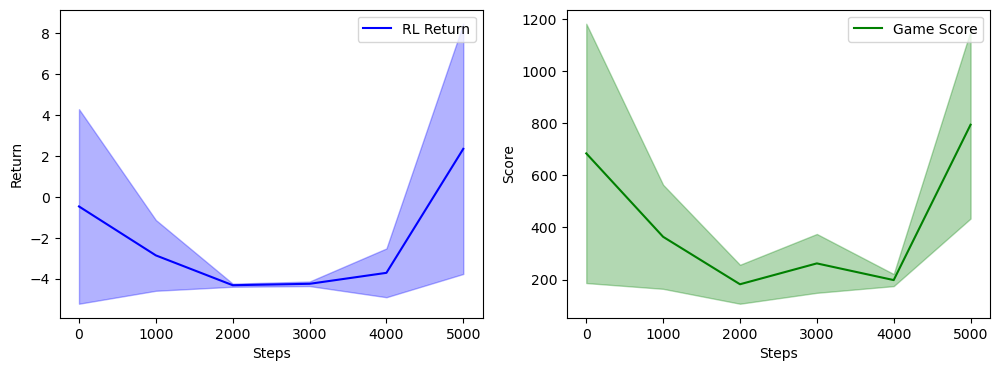

In [499]:
# Smoke test for Junimo Kart environment
env_kart = lambda: JunimoKartEnv(view_distance=20, max_time=200)

agent, eval_returns, eval_std, eval_steps, eval_scores, eval_scores_std = train_ppo(
    env_kart,
    total_steps=5000,
    rollout_length=256,
    eval_freq=1000,
    eval_rollouts=5,
    time_schedule = [300, 400],
    time_update_interval = 2000
)

# Show both charts side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(eval_steps, eval_returns, color="blue", label="RL Return")
ax[0].fill_between(eval_steps, np.array(eval_returns) - np.array(eval_std), np.array(eval_returns) + np.array(eval_std), alpha=0.3, color="blue")
ax[0].set_xlabel("Steps")
ax[0].set_ylabel("Return")
ax[0].legend()

ax[1].plot(eval_steps, eval_scores, color="green", label="Game Score")
ax[1].fill_between(eval_steps, np.array(eval_scores) - np.array(eval_scores_std), np.array(eval_scores) + np.array(eval_scores_std), alpha=0.3, color="green")
ax[1].set_xlabel("Steps")
ax[1].set_ylabel("Score")
ax[1].legend()

plt.show()

## Train and save PPO
 - Estimated 6 hours to train this with RTX 3070

In [319]:
# Curriculum
time_schedule = [250, 300, 400, 550, 700, 900, 1000, 1200]
time_update_interval = 500000

# Evaluation
evaluation_freq = 50000
evaluation_rollouts = 30

# Other, 5 Million steps used
total_steps = 5000000
rollout_length = 2048
ppo_epochs = 8
minibatch_size = 64
policy_lr = 3e-4
value_lr = 1e-3

env_kart = lambda: JunimoKartEnv(view_distance=20, max_time=200)
agent, eval_returns, eval_std, eval_steps, eval_scores, eval_scores_std = train_ppo(
    env_kart,
    total_steps=total_steps,
    rollout_length=rollout_length,
    eval_freq=evaluation_freq,
    eval_rollouts=evaluation_rollouts,
    time_schedule = time_schedule,
    time_update_interval = time_update_interval,
    ppo_epochs = ppo_epochs,
    minibatch_size = minibatch_size,
    policy_lr = policy_lr,
    value_lr = value_lr,
    save = False
)

Max time set to 200
Steps: 0| Eval RL Return: -4.15 ± 0.76 | Game Score: 150.67 ± 76.37
Steps: 50000 | Eval RL Return: -2.76 ± 4.67 | Game Score: 347.67 ± 454.77
Steps: 100000 | Eval RL Return: -2.75 ± 3.72 | Game Score: 369.33 ± 406.18
Steps: 150000 | Eval RL Return: -4.07 ± 0.83 | Game Score: 198.67 ± 137.11
Steps: 200000 | Eval RL Return: -1.87 ± 7.59 | Game Score: 508.33 ± 705.47
Steps: 250000 | Eval RL Return: -1.55 ± 5.63 | Game Score: 496.33 ± 574.16
Steps: 300000 | Eval RL Return: -3.01 ± 2.76 | Game Score: 356.33 ± 417.38
Steps: 350000 | Eval RL Return: -3.79 ± 1.17 | Game Score: 218.33 ± 246.09
Steps: 400000 | Eval RL Return: -3.20 ± 1.99 | Game Score: 339.67 ± 269.05
Steps: 450000 | Eval RL Return: -3.49 ± 2.00 | Game Score: 318.67 ± 293.92
Steps: 500000 | Eval RL Return: -1.96 ± 6.92 | Game Score: 590.33 ± 1274.62
Max time updated at step 500000, New time, 250
Steps: 550000 | Eval RL Return: -0.95 ± 8.68 | Game Score: 653.00 ± 1405.44
Steps: 600000 | Eval RL Return: -2.01 ±

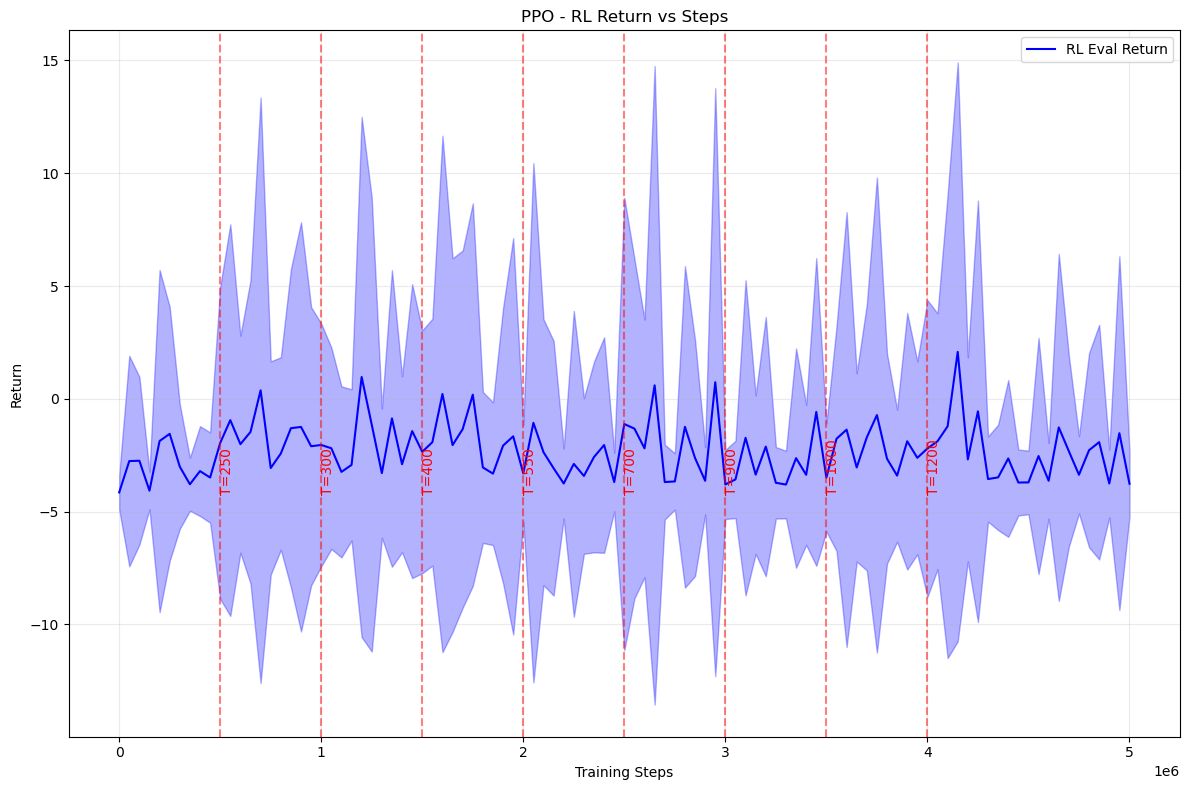

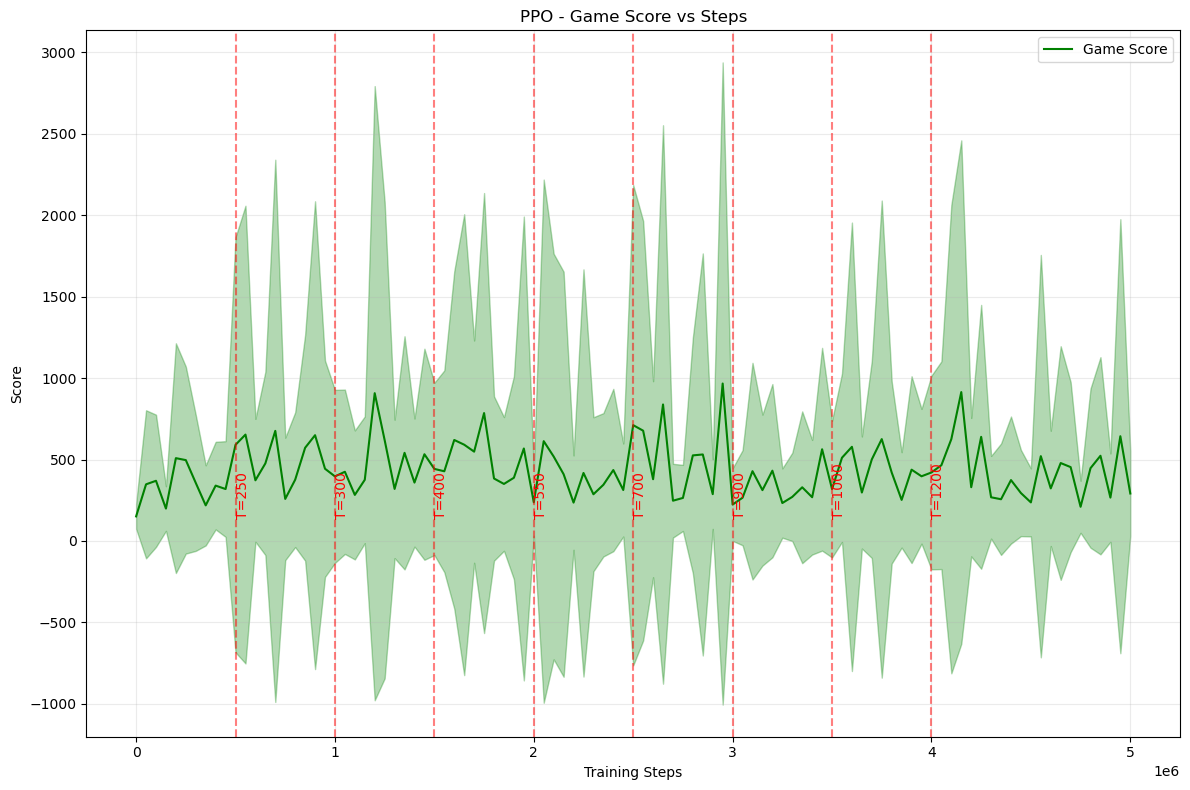

In [320]:
# Plot RL Return
plt.figure(figsize=(12, 8))
plt.plot(eval_steps, eval_returns, color="blue", label="RL Eval Return", linewidth=1.5)
plt.fill_between(eval_steps, np.array(eval_returns) - np.array(eval_std), np.array(eval_returns) + np.array(eval_std), alpha=0.3, color="blue")
if time_schedule is not None:
    for i, t in enumerate(time_schedule):
        x = (i+1) * time_update_interval
        if x <= eval_steps[-1]:
            plt.axvline(x=x, linestyle="--", color="red", alpha = 0.5)
            plt.text(x, min(eval_returns), f"T={t}", rotation=90, color="red") 

plt.title("PPO - RL Return vs Steps")
plt.xlabel("Training Steps")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("ppo_model/ppo_return_curve.png", dpi=300)
plt.show()

# Plot Final Game Score (scoring metric game tracks)
plt.figure(figsize=(12, 8))
plt.plot(eval_steps, eval_scores, color="green", label="Game Score", linewidth=1.5)
plt.fill_between(eval_steps, np.array(eval_scores) - np.array(eval_scores_std), np.array(eval_scores) + np.array(eval_scores_std), alpha=0.3, color="green")
if time_schedule is not None:
    for i, t in enumerate(time_schedule):
        x = (i+1) * time_update_interval
        if x <= eval_steps[-1]:
            plt.axvline(x=x, linestyle="--", color="red", alpha = 0.5)
            plt.text(x, min(eval_scores), f"T={t}", rotation=90, color="red") 

plt.title("PPO - Game Score vs Steps")
plt.xlabel("Training Steps")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("ppo_model/ppo_score_curve.png", dpi=300)
plt.show()

In [321]:
# Save models (simple storage of policy and value networks)
torch.save(agent.policy.state_dict(), "ppo_policy.pth")
torch.save(agent.value.state_dict(), "ppo_value.pth")

# Save full training checkpoint with metadata
dummy_env = env_kart()
tiles_shape = dummy_env.observation_space["tiles"].shape
tile_channels, tile_h, tile_w = tiles_shape
state_dim = dummy_env.observation_space["state"].shape[0]
action_dim = dummy_env.action_space.n
checkpoint = {
    "policy_state_dict": agent.policy.state_dict(),
    "value_state_dict": agent.value.state_dict(),

    # Logs
    "eval_returns": eval_returns,
    "eval_std": eval_std,
    "eval_scores": eval_scores,
    "eval_scores_std": eval_scores_std,
    "eval_steps": eval_steps,

    # Curriculum schedule
    "time_schedule": time_schedule,
    "time_update_interval": time_update_interval,

    # Architecture facts needed for rebuilding network
    "tile_channels": tile_channels,
    "tile_h": tile_h,
    "tile_w": tile_w,
    "state_dim": state_dim,
    "action_dim": action_dim,
    "hidden_size": 256,

    # Hyperparameters if needed
    "gamma": 0.99,
    "lam": 0.95,
    "eps_clip": 0.2,
    "entropy_coef": 0.02,
    "ppo_epochs": 8,
    "minibatch_size": 64,
    "policy_lr": 3e-4,
    "value_lr": 1e-3,
    "total_steps": total_steps,
    "rollout_length": rollout_length,
    "evaluation_freq": evaluation_freq,
    "evaluation_rollouts": evaluation_rollouts,
}
torch.save(checkpoint, "ppo_model/junimo_kart_ppo_result.pth")

### Create video with PPO Policy

In [323]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [562]:
# Load Policy and environment
policy = KartPolicy(tile_channels=5, tile_h=14, tile_w=20, state_dim=6, action_dim=2, hidden_size=128)
policy.load_state_dict(torch.load("ppo_policy.pth", map_location=device, weights_only=True))
policy.eval()

env = JunimoKartEnv(view_distance=20, max_time=800)
obs, info = env.reset()

# Obtain frames from policy
frames = []
for step in range(800):  # how max frames to capture
    tiles = torch.tensor(obs["tiles"], dtype=torch.float32).unsqueeze(0)
    state = torch.tensor(obs["state"], dtype=torch.float32).unsqueeze(0)
    
    with torch.no_grad():
        logits = policy(tiles, state)
        action = torch.argmax(logits, dim=1).item()

    obs, reward, terminated, truncated, info = env.step(action) # 1 step in game

    # Capture rendered frame 
    img = env.render()
    frames.append(img) # stores snapshot
    
    if terminated or truncated:
        break

# Save as video
video_path = "ppo_policy_video.mp4"
imageio.mimsave(video_path, frames, fps=15)

video_path

'ppo_policy_video.mp4'

In [563]:
Video("ppo_policy_video.mp4", embed=True)

# DDQN on Environment

In [481]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [485]:
## DDQN: Adapt earlier Q network and DDQN network
class KartQNetwork(nn.Module):
    def __init__(self, tile_channels, tile_h, tile_w, state_dim, action_dim, hidden_size=256):
        super().__init__()

        # CNN Feature extractor for our tile grid
        self.conv = nn.Sequential(
            nn.Conv2d(tile_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # Stride increase causes downsample
            nn.ReLU(),
        )

        # Dynamically find conv output dimension (default is 2240)
        with torch.no_grad():
            sample = torch.zeros(1, tile_channels, tile_h, tile_w)
            conv_out_dim = self.conv(sample).view(1, -1).size(1)

        # Small MLP for our state space (size 6 inputs)
        self.state_encoder = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
        )

        # Final Q Network combining our state and conv space
        self.fc = nn.Sequential(
            nn.Linear(conv_out_dim + 64, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, action_dim),
        )

    def forward(self, tiles, state):
        # If single state, unsqueeze to work with batching
        if len(tiles.shape) == 3:
            tiles = tiles.unsqueeze(0)
        if len(state.shape) == 1:
            state = state.unsqueeze(0)

        x_tiles = self.conv(tiles)
        x_tiles = x_tiles.flatten(start_dim=1) # Flatten starting with channels

        x_state = self.state_encoder(state)

        x = torch.cat([x_tiles, x_state], dim=1)
        x = self.fc(x)
        return x

## Replay Buffer
class ReplayBuffer:
    """Fixed-size buffer to store experience tuples."""
    def __init__(self, buffer_size):
        self.buffer = deque(maxlen=buffer_size)

    def __len__(self):
        return len(self.buffer)

    def add(self, tiles, state, action, reward, next_tiles, next_state, terminated, truncated):
        """Add a new experience to memory."""
        self.buffer.append((tiles, state, action, reward, next_tiles, next_state, terminated, truncated))

    def sample(self, batch_size):
        """Randomly sample a batch of experiences from memory."""
        batch = random.sample(self.buffer, batch_size)
        tiles, states, actions, rewards, next_tiles, next_states, terminated, truncated = zip(*batch)
        
        tiles = np.array(tiles)
        states = np.array(states)
        actions = np.array(actions)
        rewards = np.array(rewards)
        next_tiles = np.array(next_tiles)
        next_states = np.array(next_states)
        terminated = np.array(terminated)
        truncated = np.array(truncated)

        return tiles, states, actions, rewards, next_tiles, next_states, terminated, truncated

## DDQN agent to test on our game
class DDQNAgent:
    def __init__(
            self,
            tile_channels,
            tile_h,
            tile_w,
            state_dim,
            action_dim,
            lr=1e-4,
            gamma=0.99,
            buffer_size=200000,
            batch_size=64,
            target_update_freq=10000,
            epsilon_start=1.0,
            epsilon_min=0.05,
            epsilon_decay=1e-6,
            hidden_size=256
    ):
        # Hold Hyperparameters in variables for future use
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        # Epsilon with decay per episode
        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.epsilon = self.epsilon_start
        self.total_steps = 0

        # Create Q networks
        self.q_network = KartQNetwork(tile_channels, tile_h, tile_w, state_dim, action_dim, hidden_size).to(device)
        self.target_network = KartQNetwork(tile_channels, tile_h, tile_w, state_dim, action_dim, hidden_size).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict()) # Target updates to Q per target_update_freq
        self.target_network.eval()

        # Optimizer
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

        # Replay buffer
        self.replay_buffer = ReplayBuffer(buffer_size)

    ## --- Action Selection
    # Convert to tensor helper
    def _to_tensor_single(self, obs):
        tiles = torch.tensor(obs["tiles"], dtype=torch.float32, device=device).unsqueeze(0)
        state = torch.tensor(obs["state"], dtype=torch.float32, device=device).unsqueeze(0)
        return tiles, state

    # Epsilon Greedy action select
    def epsilon_select_action(self, obs):
        # Choose randomly if less than epsilon
        if np.random.rand() <= self.epsilon:
            return np.random.randint(self.action_dim)

        # Choose max otherwise
        self.q_network.eval()
        with torch.no_grad():
            tiles, state = self._to_tensor_single(obs)
            q_values = self.q_network(tiles, state)
            action = q_values.argmax(dim=1).item()
        self.q_network.train()
        return action

    # Greedy action select
    def greedy_select_action(self, obs):
        self.q_network.eval()
        with torch.no_grad():
            tiles, state = self._to_tensor_single(obs)
            q_values = self.q_network(tiles, state)
            action = q_values.argmax(dim=1).item()
        self.q_network.train()
        return action

    ## Sample from buffer and update Q network
    def update_q_network(self):
        if len(self.replay_buffer) < self.batch_size:
            return

        # Get obs and convert to tensors
        tiles, states, actions, rewards, next_tiles, next_states, terminated, truncated = self.replay_buffer.sample(self.batch_size)

        tiles = torch.tensor(tiles, dtype=torch.float32, device=device)
        states = torch.tensor(states, dtype=torch.float32, device=device)
        actions = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
        next_tiles = torch.tensor(next_tiles, dtype=torch.float32, device=device)
        next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
        terminated = torch.tensor(terminated, dtype=torch.float32, device=device).unsqueeze(1)
        truncated = torch.tensor(truncated, dtype=torch.float32, device=device).unsqueeze(1)
        
        # Q(s, a)
        q_values = self.q_network(tiles, states).gather(1, actions)

        with torch.no_grad():
            # Q(s', a')
            next_q_online = self.q_network(next_tiles, next_states)
            next_actions = next_q_online.argmax(dim=1).unsqueeze(1)
            next_q_target = self.target_network(next_tiles, next_states).gather(1, next_actions)

            # Compute the target Q values
            target_q_values = rewards + (self.gamma * next_q_target * (1 - terminated))

        # Compute the loss
        loss = F.mse_loss(q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update target network every target_update_freq
        self.total_steps += 1
        if self.total_steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        # Epsilon decay
        if self.epsilon > self.epsilon_min:
            self.epsilon -= self.epsilon_decay
            if self.epsilon < self.epsilon_min:
                self.epsilon = self.epsilon_min

In [489]:
def train_ddqn(env_kart,
               total_steps=500000,
               hidden_size=256,
               lr=1e-4,
               gamma=0.99,
               batch_size=64,
               buffer_size=200000,
               target_update_freq=10000,
               epsilon_start=1.0,
               epsilon_min=0.05,
               epsilon_decay=1e-6,
               eval_freq=5000,
               eval_rollouts=30,
               time_schedule=None,
               time_update_interval=50000):

    # Create environment (frogger-v1)
    env = env_kart()
    tiles_shape = env.observation_space["tiles"].shape
    state_shape = env.observation_space["state"].shape
    tile_channels, tile_h, tile_w = tiles_shape
    state_dim = state_shape[0]
    action_dim = env.action_space.n

    # Create Agent 
    agent = DDQNAgent(
        tile_channels=tile_channels,
        tile_h=tile_h,
        tile_w=tile_w,
        state_dim=state_dim,
        action_dim=action_dim,
        lr=lr,
        gamma=gamma,
        buffer_size=buffer_size,
        batch_size=batch_size,
        target_update_freq=target_update_freq,
        epsilon_start=epsilon_start,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay,
        hidden_size=hidden_size
    )

    # Create buffer
    eval_returns = []
    eval_std = []
    eval_steps = []
    eval_scores = []
    eval_scores_std = []

    # Evaluate inital policy
    mean_return, std_return, mean_score, std_score = evaluate_policy_ddqn(agent, env_kart, eval_rollouts)
    print(f"Max time set to {env.max_time}")
    print(f"Steps: 0| Eval RL Return: {mean_return:.2f} ± {std_return:.2f} | Game Score: {mean_score:.2f} ± {std_score:.2f}")
    
    eval_returns.append(mean_return)
    eval_std.append(std_return)
    eval_steps.append(0)
    eval_scores.append(mean_score)
    eval_scores_std.append(std_score)

    # Training loop
    steps = 0
    time_index = 0
    obs, info = env.reset()

    while steps < total_steps:
        # Collect rollout
        action = agent.epsilon_select_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        # Store transition
        agent.replay_buffer.add(obs["tiles"], obs["state"], action, reward, next_obs["tiles"], next_obs["state"], terminated, truncated)

        # Update Q network
        agent.update_q_network()
        obs = next_obs
        steps += 1

        # Handle reset
        if terminated or truncated:
            obs, info = env.reset()
        
        # Evaluation
        if steps % eval_freq == 0 or steps == total_steps:
            # Evaluate policy
            mean_return, std_return, mean_score, std_score = evaluate_policy_ddqn(agent, env_kart, eval_rollouts)
            eval_steps.append(steps)
            eval_returns.append(mean_return)
            eval_std.append(std_return)
            eval_scores.append(mean_score)
            eval_scores_std.append(std_score)
            print(f"Steps: {steps}| Eval RL Return: {mean_return:.2f} ± {std_return:.2f} | Game Score: {mean_score:.2f} ± {std_score:.2f}")
        
        # Update schedule
        if time_schedule is not None and time_index < len(time_schedule):
            if steps >= (time_index + 1) * time_update_interval:
                new_time = time_schedule[time_index]
                env.set_max_time(new_time)
                time_index += 1
                print(f"Max time updated at step {steps}, New max time: {new_time}")
        
    env.close()
    return agent, eval_returns, eval_std, eval_steps, eval_scores, eval_scores_std


# Evaluate Policy
def evaluate_policy_ddqn(agent, env_kart, n_rollouts=30):
    env = env_kart()
    rewards = []
    scores = []

    for _ in range(n_rollouts):
        obs, info = env.reset()
        terminated = False
        truncated = False
        total_reward = 0
        final_score = 0

        while not terminated and not truncated:
            action = agent.greedy_select_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            final_score = info.get("score", final_score)

        rewards.append(total_reward)
        scores.append(final_score)

    env.close()
    return np.mean(rewards), np.std(rewards), np.mean(scores), np.std(scores)

### Smoke Test
 - It looks like it generally takes longer than PPO, 4 minutes compared to 20ish seconds from PPO

Max time set to 200
Steps: 0| Eval RL Return: -3.02 ± 1.62 | Game Score: 576.00 ± 412.05
Steps: 1000| Eval RL Return: -4.29 ± 0.14 | Game Score: 206.00 ± 137.05
Steps: 2000| Eval RL Return: 0.22 ± 7.44 | Game Score: 642.00 ± 672.35
Max time updated at step 2000, New max time: 300
Steps: 3000| Eval RL Return: -1.08 ± 4.08 | Game Score: 654.00 ± 333.86
Steps: 4000| Eval RL Return: -4.18 ± 0.16 | Game Score: 322.00 ± 150.39
Max time updated at step 4000, New max time: 400
Steps: 5000| Eval RL Return: -2.84 ± 1.65 | Game Score: 380.00 ± 161.99


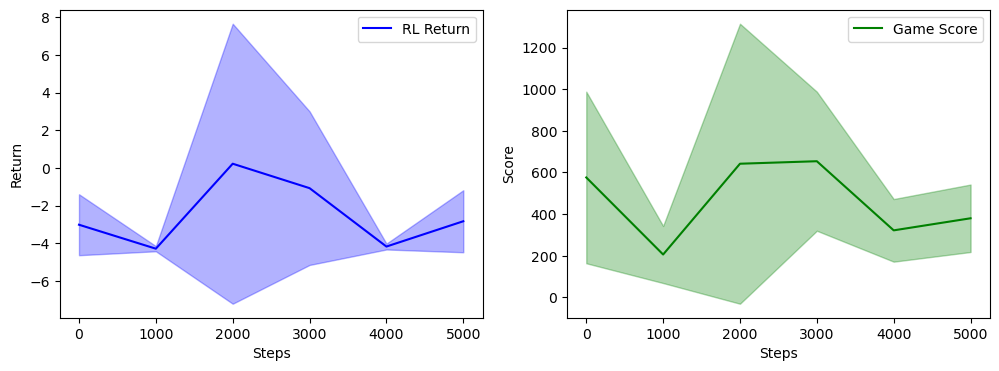

In [494]:
# Smoke test for Junimo Kart environment
env_kart = lambda: JunimoKartEnv(view_distance=20, max_time=200)

agent, eval_returns, eval_std, eval_steps, eval_scores, eval_scores_std = train_ddqn(
    env_kart,
    total_steps=5000,
    eval_freq=1000,
    eval_rollouts=5,
    time_schedule = [300, 400],
    time_update_interval = 2000
)

# Show both charts side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(eval_steps, eval_returns, color="blue", label="RL Return")
ax[0].fill_between(eval_steps, np.array(eval_returns) - np.array(eval_std), np.array(eval_returns) + np.array(eval_std), alpha=0.3, color="blue")
ax[0].set_xlabel("Steps")
ax[0].set_ylabel("Return")
ax[0].legend()

ax[1].plot(eval_steps, eval_scores, color="green", label="Game Score")
ax[1].fill_between(eval_steps, np.array(eval_scores) - np.array(eval_scores_std), np.array(eval_scores) + np.array(eval_scores_std), alpha=0.3, color="green")
ax[1].set_xlabel("Steps")
ax[1].set_ylabel("Score")
ax[1].legend()

plt.show()

## Train and save DDQN
 - Since DDQN is not as computationally efficient as PPO, I will reduce training steps to 500,000 instead of 5 million
 - With this, estimated time is around 6 and a half hours

In [515]:
# Curriculum
time_schedule = [300, 550, 900, 1200]
time_update_interval = 100000

# Evaluation
evaluation_freq = 5000
evaluation_rollouts = 30

# 500,000 steps used
total_steps = 500000
epsilon_decay=2.5e-6

env_kart = lambda: JunimoKartEnv(view_distance=20, max_time=200)
agent, eval_returns, eval_std, eval_steps, eval_scores, eval_scores_std = train_ddqn(
    env_kart,
    total_steps=total_steps,
    eval_freq=evaluation_freq,
    eval_rollouts=evaluation_rollouts,
    time_schedule=time_schedule,
    time_update_interval=time_update_interval,
    epsilon_decay=epsilon_decay
)

Max time set to 200
Steps: 0| Eval RL Return: -4.27 ± 0.55 | Game Score: 127.33 ± 73.21
Steps: 5000| Eval RL Return: -1.33 ± 4.38 | Game Score: 513.00 ± 503.58
Steps: 10000| Eval RL Return: -1.08 ± 4.83 | Game Score: 542.33 ± 467.70
Steps: 15000| Eval RL Return: 1.24 ± 8.01 | Game Score: 879.33 ± 775.94
Steps: 20000| Eval RL Return: -0.01 ± 5.96 | Game Score: 757.33 ± 606.82
Steps: 25000| Eval RL Return: -0.22 ± 7.42 | Game Score: 612.00 ± 624.76
Steps: 30000| Eval RL Return: 0.03 ± 6.89 | Game Score: 631.00 ± 575.13
Steps: 35000| Eval RL Return: 1.58 ± 11.33 | Game Score: 1056.33 ± 1839.08
Steps: 40000| Eval RL Return: -0.44 ± 6.27 | Game Score: 637.00 ± 611.49
Steps: 45000| Eval RL Return: 1.32 ± 10.41 | Game Score: 857.33 ± 1466.73
Steps: 50000| Eval RL Return: -0.08 ± 7.06 | Game Score: 779.33 ± 1239.58
Steps: 55000| Eval RL Return: -0.27 ± 8.56 | Game Score: 643.33 ± 713.38
Steps: 60000| Eval RL Return: 0.98 ± 8.18 | Game Score: 719.67 ± 729.25
Steps: 65000| Eval RL Return: -0.17 

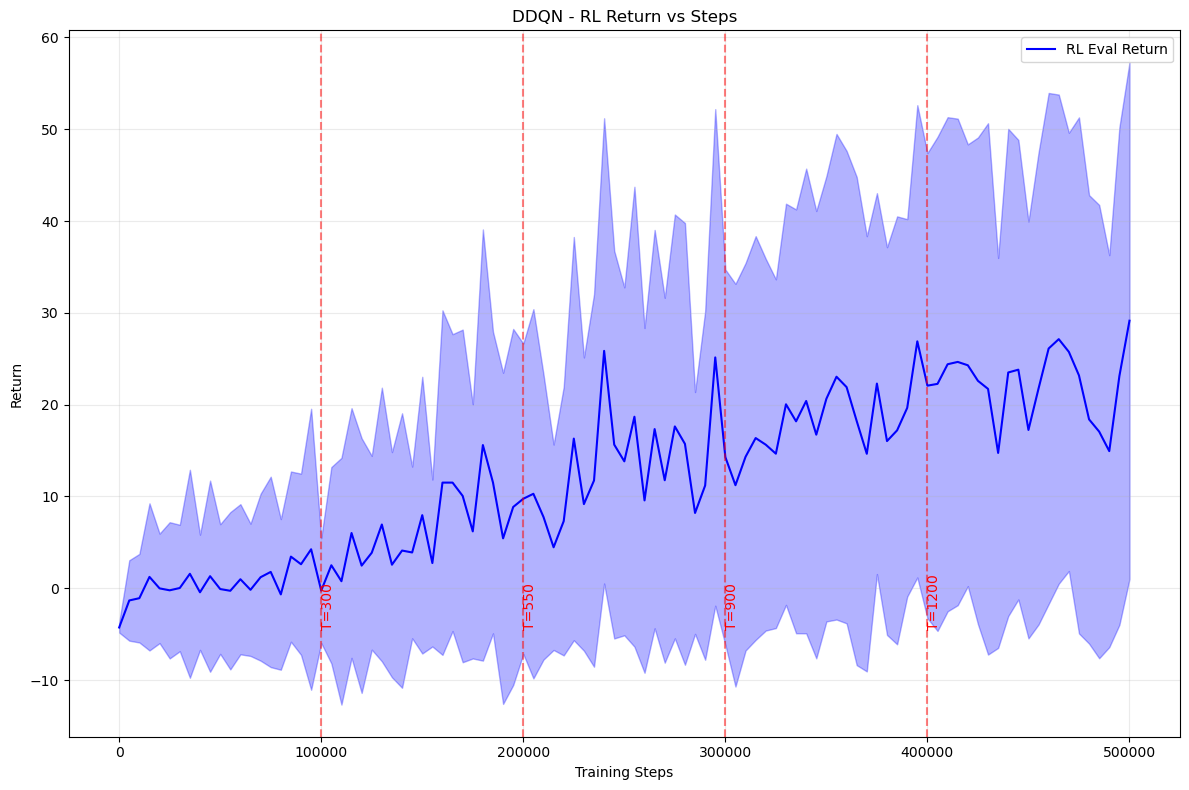

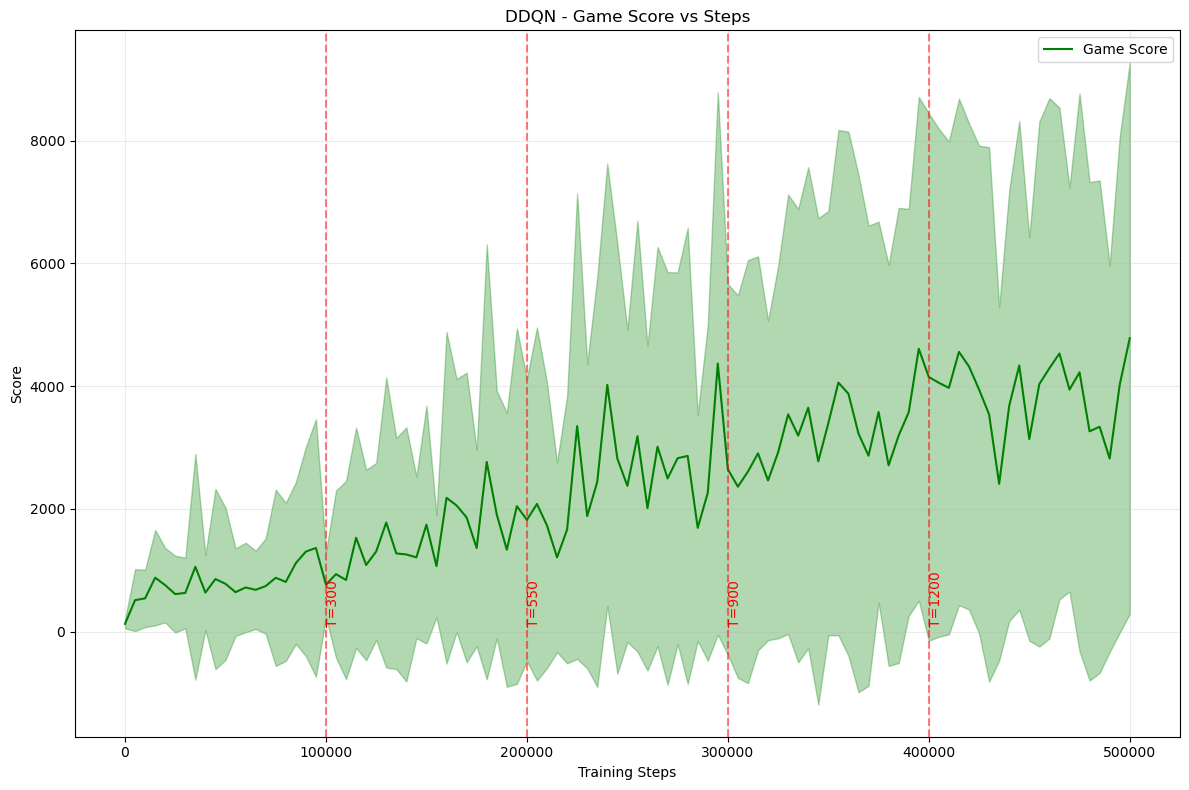

In [516]:
# Plot RL Return
plt.figure(figsize=(12, 8))
plt.plot(eval_steps, eval_returns, color="blue", label="RL Eval Return", linewidth=1.5)
plt.fill_between(eval_steps, np.array(eval_returns) - np.array(eval_std), np.array(eval_returns) + np.array(eval_std), alpha=0.3, color="blue")
if time_schedule is not None:
    for i, t in enumerate(time_schedule):
        x = (i+1) * time_update_interval
        if x <= eval_steps[-1]:
            plt.axvline(x=x, linestyle="--", color="red", alpha = 0.5)
            plt.text(x, min(eval_returns), f"T={t}", rotation=90, color="red") 

plt.title("DDQN - RL Return vs Steps")
plt.xlabel("Training Steps")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("ddqn_model/ddqn_return_curve.png", dpi=300)
plt.show()

# Plot Final Game Score (scoring metric game tracks)
plt.figure(figsize=(12, 8))
plt.plot(eval_steps, eval_scores, color="green", label="Game Score", linewidth=1.5)
plt.fill_between(eval_steps, np.array(eval_scores) - np.array(eval_scores_std), np.array(eval_scores) + np.array(eval_scores_std), alpha=0.3, color="green")
if time_schedule is not None:
    for i, t in enumerate(time_schedule):
        x = (i+1) * time_update_interval
        if x <= eval_steps[-1]:
            plt.axvline(x=x, linestyle="--", color="red", alpha = 0.5)
            plt.text(x, min(eval_scores), f"T={t}", rotation=90, color="red") 

plt.title("DDQN - Game Score vs Steps")
plt.xlabel("Training Steps")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("ddqn_model/ddqn_score_curve.png", dpi=300)
plt.show()

In [517]:
# Save models (simple storage of policy and value networks)
torch.save(agent.q_network.state_dict(), "ddqn_network.pth")

checkpoint = {
    "q_network_state_dict": agent.q_network.state_dict(),
    "target_network_state_dict": agent.target_network.state_dict(),

    "eval_returns": eval_returns,
    "eval_std": eval_std,
    "eval_scores": eval_scores,
    "eval_scores_std": eval_scores_std,
    "eval_steps": eval_steps,

    "time_schedule": time_schedule,
    "time_update_interval": time_update_interval,

    "tile_channels": tile_channels,
    "tile_h": tile_h,
    "tile_w": tile_w,
    "state_dim": state_dim,
    "action_dim": action_dim,
    "hidden_size": 256, # Was 256 for this DDQN

    "gamma": agent.gamma,
    "lr": agent.optimizer.param_groups[0]["lr"],
    "epsilon": agent.epsilon,
    "epsilon_min": agent.epsilon_min,
    "epsilon_decay": agent.epsilon_decay,
    "total_steps": total_steps,
}
torch.save(checkpoint, "ddqn_model/junimo_kart_ddqn_result.pth")


### Create video with DDQN Network

In [624]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [630]:
# Load Policy and environment
q_network = KartQNetwork(tile_channels=5, tile_h=14, tile_w=20, state_dim=6, action_dim=2, hidden_size=256)
q_network.load_state_dict(torch.load("ddqn_network.pth", map_location=device, weights_only=True))
q_network.eval()

env = JunimoKartEnv(view_distance=20, max_time=800)
obs, info = env.reset()

# Obtain frames from policy
frames = []
for step in range(800):  # how max frames to capture
    tiles = torch.tensor(obs["tiles"], dtype=torch.float32).unsqueeze(0)
    state = torch.tensor(obs["state"], dtype=torch.float32).unsqueeze(0)
    
    with torch.no_grad():
        q_values = q_network(tiles, state)
        action = torch.argmax(q_values, dim=1).item()

    obs, reward, terminated, truncated, info = env.step(action) # 1 step in game

    # Capture rendered frame 
    img = env.render()
    frames.append(img) # stores snapshot
    
    if terminated or truncated:
        break

# Save as video
video_path = "ddqn_video.mp4"
imageio.mimsave(video_path, frames, fps=15)

video_path

'ddqn_video.mp4'

In [631]:
Video("ddqn_video.mp4", embed=True)